In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/



Import additional libraries


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import cv2
from skimage.measure import shannon_entropy
from sklearn.preprocessing import MinMaxScaler

In [4]:
ROOT = "/content/drive/My Drive/Eye Disease/Dataset"

CSV_PATH = os.path.join(ROOT, "full_df.csv")

TRAIN_DIR = os.path.join(ROOT, "ODIR-5K", "ODIR-5K" ,"Training Images")

TEST_DIR = os.path.join(ROOT, "ODIR-5K","ODIR-5K", "Testing Images")

PREPROCESS_DIR = os.path.join(ROOT, "preprocessed_images")

In [5]:
stage1 = pd.read_csv(os.path.join(ROOT, "stage1_train_df.csv"))
print("Train:", stage1.shape)


Train: (4491, 13)


Define Quality Metric Functions

In [6]:
# IMAGE QUALITY METRICS

def calculate_blur(image):
    """
    Blur Score using Variance of Laplacian.
    Higher value = Sharper Image
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()


def calculate_brightness(image):
    """
    Average brightness.
    Higher value = Brighter Image
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return np.mean(gray)


def calculate_contrast(image):
    """
    Standard deviation of pixel intensities.
    Higher value = Better Contrast
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return np.std(gray)


def calculate_entropy(image):
    """
    Shannon Entropy.
    Higher value = More information/content.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return shannon_entropy(gray)

Compute Metrics for All Images

In [39]:
import pandas as pd


# ============================================================
# CALCULATE QUALITY METRICS FOR PATIENT-LEVEL SPLITS
# ============================================================

def calculate_quality_for_split(split_df, split_name):

    quality_metrics = []

    # Get image filenames from the patient-level dataframe
    image_files = split_df["filename"].tolist()

    print(f"{split_name} - Total Images: {len(image_files)}")

    for image_name in tqdm(
        image_files,
        desc=f"Calculating quality - {split_name}"
    ):

        image_path = os.path.join(
            PREPROCESS_DIR,
            image_name
        )

        image = cv2.imread(image_path)

        if image is None:
            continue

        blur = calculate_blur(image)
        brightness = calculate_brightness(image)
        contrast = calculate_contrast(image)
        entropy = calculate_entropy(image)

        quality_metrics.append({
            "filename": image_name,
            "blur": blur,
            "brightness": brightness,
            "contrast": contrast,
            "entropy": entropy
        })

    return pd.DataFrame(quality_metrics)


# ============================================================
# COMPUTE AND SAVE RAW TRAINING QUALITY METRICS
# ============================================================

train_quality_df = calculate_quality_for_split(
    stage1,
    "Training"
)

# ------------------------------------------------------------
# Save the RAW metrics
# ------------------------------------------------------------

raw_metrics_path = os.path.join(
    ROOT,
    "train_quality_metrics.csv"
)

train_quality_df.to_csv(
    raw_metrics_path,
    index=False
)

print("=" * 70)
print("RAW TRAINING QUALITY METRICS SAVED")
print("=" * 70)

print(
    "File:",
    raw_metrics_path
)

print(
    "Training images:",
    len(train_quality_df)
)

print(
    "Columns:",
    train_quality_df.columns.tolist()
)

display(
    train_quality_df.head()
)

Training - Total Images: 4491


Calculating quality - Training: 100%|██████████| 4491/4491 [20:10<00:00,  3.71it/s]

RAW TRAINING QUALITY METRICS SAVED
File: /content/drive/My Drive/Eye Disease/Dataset/train_quality_metrics.csv
Training images: 4491
Columns: ['filename', 'blur', 'brightness', 'contrast', 'entropy']


,filename,blur,brightness,contrast,entropy
0,1_right.jpg,288.084104,99.023312,58.061142,6.167973
1,1_left.jpg,352.838359,101.571117,57.564232,5.945882
2,2_right.jpg,138.147789,50.526344,32.425547,5.613976
3,3_left.jpg,96.277859,85.102959,55.265608,5.416552
4,4_right.jpg,647.935590,101.203934,55.847019,6.304848


Reading file from drive(To load existing computed quality scores)

In [7]:
# ============================================================
# LOAD EXISTING QUALITY SCORES FROM DRIVE
# ============================================================

train_quality_scores_path = os.path.join(
    ROOT,
    "train_quality_metrics.csv"
)


# Read existing files
train_quality_df = pd.read_csv(
    train_quality_scores_path
)



print("Quality score files loaded successfully.")

print("Train:", len(train_quality_df))


Quality score files loaded successfully.
Train: 4491


NOrmalizing all the metrics  then combine them in next step

In [8]:
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# NORMALIZE QUALITY FEATURES
# ============================================================

quality_columns = [
    "blur",
    "brightness",
    "contrast",
    "entropy"
]

# Initialize Min-Max Scaler
scaler = MinMaxScaler()

# Fit scaler ONLY on training data
train_normalized_df = train_quality_df.copy()

train_normalized_df[quality_columns] = scaler.fit_transform(
    train_normalized_df[quality_columns]
)

print("Quality metrics normalized successfully.")

print("Train:", len(train_normalized_df))

train_normalized_df.head(20)



Quality metrics normalized successfully.
Train: 4491


,filename,blur,brightness,contrast,entropy
0,1_right.jpg,0.163816,0.512380,0.538071,0.652204
1,1_left.jpg,0.201001,0.526298,0.532906,0.590627
2,2_right.jpg,0.077715,0.247452,0.271572,0.498602
3,3_left.jpg,0.053671,0.436336,0.509010,0.443864
4,4_right.jpg,0.370460,0.524292,0.515054,0.690154
5,4_left.jpg,0.322187,0.482356,0.606808,0.852535
6,5_right.jpg,0.161948,0.468024,0.441007,0.535494
7,5_left.jpg,0.120036,0.367410,0.363011,0.547928
8,6_right.jpg,0.249354,0.616421,0.662468,0.674266
9,6_left.jpg,0.229817,0.598796,0.656289,0.704355


## Controlled Degradation Experiment — Setup

We now determine the quality-score weighting scheme empirically rather than assigning
handcrafted weights.

Only Stage-1 training images are used in this experiment. Validation and test images
are not involved in selecting the quality weights.

A controlled degradation is applied to selected training images at increasing severity.
The same four image-quality metrics are then recalculated for each degraded image.

The four degradation families are:

1. Blur
2. Brightness distortion
3. Contrast reduction
4. Gaussian noise

The purpose is not to establish medical ground truth. Instead, the experiment measures
whether the proposed objective quality metrics respond consistently to known increases
in image degradation.

The resulting behavior will be used to compare several candidate weighting schemes.

In [9]:
# ============================================================
# STEP 1 — CONTROLLED DEGRADATION EXPERIMENT SETUP
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from scipy.stats import spearmanr
from sklearn.preprocessing import MinMaxScaler


# ------------------------------------------------------------
# Quality metrics already defined in the notebook
# ------------------------------------------------------------

quality_columns = [
    "blur",
    "brightness",
    "contrast",
    "entropy"
]


# ------------------------------------------------------------
# Verify that raw training metrics are available
# ------------------------------------------------------------

if "train_quality_df" not in globals():
    raise RuntimeError(
        "train_quality_df is not available. "
        "Run the raw quality-metric calculation cell first."
    )


required_columns = ["filename"] + quality_columns

missing_columns = [
    col for col in required_columns
    if col not in train_quality_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )


# ------------------------------------------------------------
# Verify metric values
# ------------------------------------------------------------

if train_quality_df[quality_columns].isna().any().any():
    raise ValueError(
        "Missing values found in raw quality metrics."
    )

if not np.isfinite(
    train_quality_df[quality_columns].to_numpy(dtype=float)
).all():
    raise ValueError(
        "Non-finite values found in raw quality metrics."
    )


# ------------------------------------------------------------
# Experiment settings
# ------------------------------------------------------------

DEGRADATION_SAMPLE_SIZE = min(
    300,
    len(train_quality_df)
)

DEGRADATION_RANDOM_STATE = 42

DEGRADATION_LEVELS = {
    "blur": [1.0, 2.0, 3.0, 4.0],

    "brightness": [
        0.85,
        0.70,
        0.55,
        0.40
    ],

    "contrast": [
        0.85,
        0.70,
        0.55,
        0.40
    ],

    "noise": [
        5.0,
        10.0,
        20.0,
        30.0
    ]
}


print("=" * 70)
print("CONTROLLED DEGRADATION EXPERIMENT")
print("=" * 70)

print("Total Stage-1 training eyes:", len(train_quality_df))
print("Images used for degradation experiment:", DEGRADATION_SAMPLE_SIZE)
print("Quality metrics:", quality_columns)
print("Degradation families:", list(DEGRADATION_LEVELS.keys()))

CONTROLLED DEGRADATION EXPERIMENT
Total Stage-1 training eyes: 4491
Images used for degradation experiment: 300
Quality metrics: ['blur', 'brightness', 'contrast', 'entropy']
Degradation families: ['blur', 'brightness', 'contrast', 'noise']


## Select Training Images for Controlled Degradation

A fixed subset of Stage-1 training eyes is selected for the degradation experiment.

The subset is selected using a fixed random seed so that the experiment is reproducible.

These images remain the clean reference images. Each image will later receive multiple
controlled degradation levels.

No validation or test images are used.

In [10]:
# ============================================================
# STEP 2 — SELECT TRAINING IMAGES
# ============================================================

degradation_subset = train_quality_df.sample(
    n=DEGRADATION_SAMPLE_SIZE,
    random_state=DEGRADATION_RANDOM_STATE
).copy()

degradation_subset = degradation_subset.reset_index(drop=True)


print("=" * 70)
print("DEGRADATION SUBSET")
print("=" * 70)

print(
    "Selected training images:",
    len(degradation_subset)
)

display(
    degradation_subset[
        ["filename"] + quality_columns
    ].head()
)

DEGRADATION SUBSET
Selected training images: 300


,filename,blur,brightness,contrast,entropy
0,138_left.jpg,85.649679,57.151505,34.941693,5.351673
1,2666_right.jpg,184.234874,67.843723,44.773019,5.835538
2,876_right.jpg,235.618598,72.284184,45.528220,6.042691
3,957_right.jpg,166.555851,81.909645,51.258785,6.123712
4,649_left.jpg,148.744030,80.764278,46.783543,5.510566


## Step 3 — Define Controlled Degradation Functions

We define one unified degradation function that applies four controlled
perturbation families at known severity levels:

1. Blur
2. Brightness distortion
3. Contrast reduction
4. Gaussian noise

The severity parameter has a known ordering, allowing us to test how the four
quality metrics respond as degradation increases.

A unified function is used so that the same experimental procedure is applied
consistently to every selected training image.

In [11]:
# ============================================================
# STEP 3 — CONTROLLED DEGRADATION FUNCTION
# ============================================================

def apply_degradation(
    image,
    degradation_type,
    severity
):
    """
    Apply one controlled degradation at a known severity.
    """

    # --------------------------------------------------------
    # BLUR
    # Larger sigma = stronger blur
    # --------------------------------------------------------

    if degradation_type == "blur":

        return cv2.GaussianBlur(
            image,
            (0, 0),
            sigmaX=severity
        )

    # --------------------------------------------------------
    # BRIGHTNESS
    # Smaller factor = stronger darkening
    # --------------------------------------------------------

    if degradation_type == "brightness":

        result = (
            image.astype(np.float32)
            * severity
        )

        return np.clip(
            result,
            0,
            255
        ).astype(np.uint8)

    # --------------------------------------------------------
    # CONTRAST
    # Smaller factor = stronger contrast reduction
    # --------------------------------------------------------

    if degradation_type == "contrast":

        result = (
            image.astype(np.float32) - 127.5
        ) * severity + 127.5

        return np.clip(
            result,
            0,
            255
        ).astype(np.uint8)

    # --------------------------------------------------------
    # GAUSSIAN NOISE
    # Larger sigma = stronger noise
    # --------------------------------------------------------

    if degradation_type == "noise":

        # Fixed seed makes the experiment reproducible
        rng = np.random.default_rng(
            DEGRADATION_RANDOM_STATE
            + int(severity * 100)
        )

        noise = rng.normal(
            loc=0.0,
            scale=severity,
            size=image.shape
        )

        result = (
            image.astype(np.float32)
            + noise
        )

        return np.clip(
            result,
            0,
            255
        ).astype(np.uint8)

    # --------------------------------------------------------
    # Unknown degradation
    # --------------------------------------------------------

    raise ValueError(
        f"Unknown degradation type: {degradation_type}"
    )


print(
    "Unified degradation function defined successfully."
)

Unified degradation function defined successfully.


## Step 4 — Sanity Check the Degradation Transformations

Before running the complete degradation experiment, we test each degradation
function on one actual Stage-1 training image.

This verifies that the transformations execute correctly on the images used by
our existing pipeline.

The four transformations tested are:

1. Gaussian blur
2. Brightness distortion
3. Contrast reduction
4. Gaussian noise

This is only a technical sanity check. No human quality judgment or medical
annotation is performed.

In [12]:
# ============================================================
# STEP 4 — SANITY CHECK DEGRADATION TRANSFORMATIONS
# ============================================================

# ------------------------------------------------------------
# Select one image from the degradation subset
# ------------------------------------------------------------

sample_filename = degradation_subset.iloc[0]["filename"]

sample_path = os.path.join(
    PREPROCESS_DIR,
    sample_filename
)

# ------------------------------------------------------------
# Load the image
# ------------------------------------------------------------

sample_image = cv2.imread(sample_path)

if sample_image is None:
    raise FileNotFoundError(
        f"Could not read image:\n{sample_path}"
    )

# ------------------------------------------------------------
# Apply one mild degradation from each family
# ------------------------------------------------------------

test_blur = apply_degradation(
    sample_image,
    "blur",
    DEGRADATION_LEVELS["blur"][0]
)

test_brightness = apply_degradation(
    sample_image,
    "brightness",
    DEGRADATION_LEVELS["brightness"][0]
)

test_contrast = apply_degradation(
    sample_image,
    "contrast",
    DEGRADATION_LEVELS["contrast"][0]
)

test_noise = apply_degradation(
    sample_image,
    "noise",
    DEGRADATION_LEVELS["noise"][0]
)

# ------------------------------------------------------------
# Verify outputs
# ------------------------------------------------------------

print("=" * 70)
print("DEGRADATION SANITY CHECK")
print("=" * 70)

print("Filename:", sample_filename)
print("Original image shape:", sample_image.shape)
print()

print("Blur output shape:", test_blur.shape)
print("Brightness output shape:", test_brightness.shape)
print("Contrast output shape:", test_contrast.shape)
print("Noise output shape:", test_noise.shape)

print()

print("Original dtype:", sample_image.dtype)
print("Blur dtype:", test_blur.dtype)
print("Brightness dtype:", test_brightness.dtype)
print("Contrast dtype:", test_contrast.dtype)
print("Noise dtype:", test_noise.dtype)

print()
print("All degradation transformations executed successfully.")

DEGRADATION SANITY CHECK
Filename: 138_left.jpg
Original image shape: (512, 512, 3)

Blur output shape: (512, 512, 3)
Brightness output shape: (512, 512, 3)
Contrast output shape: (512, 512, 3)
Noise output shape: (512, 512, 3)

Original dtype: uint8
Blur dtype: uint8
Brightness dtype: uint8
Contrast dtype: uint8
Noise dtype: uint8

All degradation transformations executed successfully.


## Step 5 — Generate the Controlled Degradation Dataset

Each selected Stage-1 training image is treated as a clean reference.

For every image, we retain the original clean metrics and generate four controlled
degradation families at four increasing severity levels:

- Blur
- Brightness distortion
- Contrast reduction
- Gaussian noise

The same four quality metrics are recalculated for every degraded image.

This produces an experimental dataset in which degradation severity is known by
construction. It allows us to measure whether each metric responds predictably
to increasing degradation.

For every one of your 300 selected training images, we'll keep:

clean
   +
 + blur:       severity 1, 2, 3, 4
 + brightness: severity 1, 2, 3, 4
 + contrast:   severity 1, 2, 3, 4
 + noise:      severity 1, 2, 3, 4

So each image gives:

1 clean + 4 blur + 4 brightness + 4 contrast + 4 noise
= 17 observations

For 300 images:

300 × 17 = 5,100 experimental observations.

That's manageable and doesn't involve any model training.

No human quality ratings are used, and no validation or test images are involved.

In [13]:
# ============================================================
# STEP 5 — RUN CONTROLLED DEGRADATION EXPERIMENT
# ============================================================

degradation_records = []

# ------------------------------------------------------------
# Process every selected training image
# ------------------------------------------------------------

for _, row in tqdm(
    degradation_subset.iterrows(),
    total=len(degradation_subset),
    desc="Running degradation experiment"
):

    image_path = os.path.join(
        PREPROCESS_DIR,
        row["filename"]
    )

    image = cv2.imread(image_path)

    if image is None:
        print(
            f"WARNING: Could not read {row['filename']}"
        )
        continue

    # --------------------------------------------------------
    # 1. CLEAN REFERENCE
    # --------------------------------------------------------

    clean_metrics = {
        "blur": calculate_blur(image),
        "brightness": calculate_brightness(image),
        "contrast": calculate_contrast(image),
        "entropy": calculate_entropy(image)
    }

    degradation_records.append({
        "filename": row["filename"],
        "degradation": "clean",
        "severity": 0,
        **clean_metrics
    })

    # --------------------------------------------------------
    # 2. CONTROLLED DEGRADATIONS
    # --------------------------------------------------------

    for degradation_type, levels in DEGRADATION_LEVELS.items():

        for severity_index, severity_value in enumerate(
            levels,
            start=1
        ):

            # Apply controlled degradation
            degraded_image = apply_degradation(
                image,
                degradation_type,
                severity_value
            )

            # Recalculate the SAME four metrics
            degraded_metrics = {
                "blur": calculate_blur(degraded_image),
                "brightness": calculate_brightness(degraded_image),
                "contrast": calculate_contrast(degraded_image),
                "entropy": calculate_entropy(degraded_image)
            }

            degradation_records.append({
                "filename": row["filename"],
                "degradation": degradation_type,
                "severity": severity_index,
                **degraded_metrics
            })


# ------------------------------------------------------------
# Convert results to DataFrame
# ------------------------------------------------------------

degradation_df = pd.DataFrame(
    degradation_records
)


# ------------------------------------------------------------
# Basic verification
# ------------------------------------------------------------

print("=" * 70)
print("CONTROLLED DEGRADATION EXPERIMENT COMPLETE")
print("=" * 70)

print(
    "Experimental records:",
    len(degradation_df)
)

print(
    "Unique training images:",
    degradation_df["filename"].nunique()
)

print(
    "Degradation types:",
    degradation_df["degradation"].unique().tolist()
)

print()

display(
    degradation_df.head(10)
)

Running degradation experiment:   0%|          | 0/300 [00:00<?, ?it/s]

CONTROLLED DEGRADATION EXPERIMENT COMPLETE
Experimental records: 5100
Unique training images: 300
Degradation types: ['clean', 'blur', 'brightness', 'contrast', 'noise']



,filename,degradation,severity,blur,brightness,contrast,entropy
0,138_left.jpg,clean,0,85.649679,57.151505,34.941693,5.351673
1,138_left.jpg,blur,1,5.517338,57.148228,34.711208,5.393641
2,138_left.jpg,blur,2,1.938729,57.150581,34.441641,5.449978
3,138_left.jpg,blur,3,1.366047,57.161083,34.177419,5.519683
4,138_left.jpg,blur,4,1.202383,57.167412,33.917893,5.597094
5,138_left.jpg,brightness,1,62.665208,48.180305,29.547663,5.108611
6,138_left.jpg,brightness,2,43.080571,39.652462,24.321328,4.896260
7,138_left.jpg,brightness,3,26.965773,31.042915,19.058355,4.604700
8,138_left.jpg,brightness,4,14.933810,22.535545,13.846036,4.233979
9,138_left.jpg,contrast,1,62.699681,67.269817,29.585586,5.110598


## Step 6 — Recover the Clean Raw Training Metrics

The degradation experiment must use the original raw image-quality metrics as its
reference distribution.

The current `train_quality_df` object has been found to contain normalized values,
as shown by its metric ranges of 0 to 1.

Therefore, we explicitly reload the previously saved raw training-metric file.
This prevents normalized data from accidentally being used as the reference
distribution.

The raw metrics will be verified before the degradation metrics are normalized.

In [15]:
# ============================================================
# STEP 6 — LOAD AND VERIFY TRUE RAW TRAINING METRICS
# ============================================================

# ------------------------------------------------------------
# Path to the RAW metric file
# ------------------------------------------------------------

raw_metrics_path = os.path.join(
    ROOT,
    "train_quality_metrics.csv"
)

# ------------------------------------------------------------
# Reload the raw metrics explicitly
# ------------------------------------------------------------

raw_train_quality_df = pd.read_csv(
    raw_metrics_path
)

# ------------------------------------------------------------
# Verify required columns
# ------------------------------------------------------------

required_columns = [
    "filename",
    "blur",
    "brightness",
    "contrast",
    "entropy"
]

missing_columns = [
    col
    for col in required_columns
    if col not in raw_train_quality_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns in raw metrics file: {missing_columns}"
    )

# ------------------------------------------------------------
# Verify that these are actually RAW values
# ------------------------------------------------------------

raw_ranges = pd.DataFrame({
    "metric": quality_columns,
    "minimum": [
        raw_train_quality_df[col].min()
        for col in quality_columns
    ],
    "maximum": [
        raw_train_quality_df[col].max()
        for col in quality_columns
    ]
})

print("=" * 70)
print("RAW TRAINING METRIC VERIFICATION")
print("=" * 70)

print(
    "Number of training images:",
    len(raw_train_quality_df)
)

display(raw_ranges)

print()
print("First five raw observations:")

display(
    raw_train_quality_df[
        required_columns
    ].head()
)

RAW TRAINING METRIC VERIFICATION
Number of training images: 4491


,metric,minimum,maximum
0,blur,2.814586,1744.217682
1,brightness,5.228615,188.285507
2,contrast,6.301911,102.495922
3,entropy,3.815665,7.422370



First five raw observations:


,filename,blur,brightness,contrast,entropy
0,1_right.jpg,288.084104,99.023312,58.061142,6.167973
1,1_left.jpg,352.838359,101.571117,57.564232,5.945882
2,2_right.jpg,138.147789,50.526344,32.425547,5.613976
3,3_left.jpg,96.277859,85.102959,55.265608,5.416552
4,4_right.jpg,647.935590,101.203934,55.847019,6.304848


## Step 7 — Fit the Clean Training Reference Scaler

The Min-Max scaler is fitted exclusively on the verified raw quality metrics from
the Stage-1 training set.

This creates the fixed numerical reference used to normalize both clean and
degraded observations.

The scaler is fitted once and is not refitted on the degradation experiment.

In [16]:
# ============================================================
# STEP 7 — FIT SCALER ON TRUE RAW TRAINING METRICS
# ============================================================

degradation_scaler = MinMaxScaler()

degradation_scaler.fit(
    raw_train_quality_df[quality_columns]
)

print("=" * 70)
print("CLEAN TRAINING REFERENCE SCALER")
print("=" * 70)

scaler_range_df = pd.DataFrame({
    "metric": quality_columns,
    "training_min": degradation_scaler.data_min_,
    "training_max": degradation_scaler.data_max_
})

display(scaler_range_df)

CLEAN TRAINING REFERENCE SCALER


,metric,training_min,training_max
0,blur,2.814586,1744.217682
1,brightness,5.228615,188.285507
2,contrast,6.301911,102.495922
3,entropy,3.815665,7.422370


## Step 8 — Normalize the Controlled Degradation Dataset

The degradation observations are transformed using the scaler fitted on the
verified raw Stage-1 training distribution.

The scaler is not refitted on degraded observations.

Therefore, every clean and degraded image is represented relative to the same
fixed clean-training reference.

In [17]:
# ============================================================
# STEP 8 — NORMALIZE DEGRADATION DATA
# ============================================================

degradation_normalized_df = degradation_df.copy()

degradation_normalized_df[quality_columns] = (
    degradation_scaler.transform(
        degradation_df[quality_columns]
    )
)

# ------------------------------------------------------------
# Compare raw and normalized values
# ------------------------------------------------------------

comparison_df = degradation_df[
    ["filename", "degradation", "severity"] + quality_columns
].head(10).copy()

for metric in quality_columns:

    comparison_df[
        metric + "_normalized"
    ] = degradation_normalized_df[
        metric
    ].head(10).values


print("=" * 70)
print("RAW VS NORMALIZED DEGRADATION METRICS")
print("=" * 70)

display(comparison_df)

RAW VS NORMALIZED DEGRADATION METRICS


,filename,degradation,severity,blur,brightness,contrast,entropy,blur_normalized,brightness_normalized,contrast_normalized,entropy_normalized
0,138_left.jpg,clean,0,85.649679,57.151505,34.941693,5.351673,0.047568,0.283643,0.297729,0.425876
1,138_left.jpg,blur,1,5.517338,57.148228,34.711208,5.393641,0.001552,0.283626,0.295333,0.437512
2,138_left.jpg,blur,2,1.938729,57.150581,34.441641,5.449978,-0.000503,0.283638,0.292531,0.453132
3,138_left.jpg,blur,3,1.366047,57.161083,34.177419,5.519683,-0.000832,0.283696,0.289784,0.472458
4,138_left.jpg,blur,4,1.202383,57.167412,33.917893,5.597094,-0.000926,0.283730,0.287086,0.493921
5,138_left.jpg,brightness,1,62.665208,48.180305,29.547663,5.108611,0.034369,0.234636,0.241655,0.358484
6,138_left.jpg,brightness,2,43.080571,39.652462,24.321328,4.896260,0.023123,0.188050,0.187324,0.299607
7,138_left.jpg,brightness,3,26.965773,31.042915,19.058355,4.604700,0.013869,0.141018,0.132612,0.218769
8,138_left.jpg,brightness,4,14.933810,22.535545,13.846036,4.233979,0.006959,0.094544,0.078426,0.115982
9,138_left.jpg,contrast,1,62.699681,67.269817,29.585586,5.110598,0.034389,0.338918,0.242049,0.359035


## Step 9 — Analyze Metric Response to Controlled Degradation

We now evaluate how each quality metric responds as the known degradation
severity increases.

For each degradation family, Spearman correlation is calculated between
degradation severity and each normalized quality metric.

Spearman correlation is used because the experiment is primarily interested in
whether a metric changes consistently as degradation increases, rather than
assuming a linear relationship.

The results describe empirical metric sensitivity to the controlled
perturbations. They are not treated as medical ground truth and are not used
to claim that one metric is universally more important than another.

In [18]:
# ============================================================
# STEP 9 — ANALYZE METRIC RESPONSE TO DEGRADATION
# ============================================================

from scipy.stats import spearmanr

metric_behavior_records = []

degradation_types = [
    "blur",
    "brightness",
    "contrast",
    "noise"
]

for degradation_type in degradation_types:

    subset = degradation_normalized_df[
        degradation_normalized_df["degradation"]
        == degradation_type
    ].copy()

    for metric in quality_columns:

        rho, p_value = spearmanr(
            subset["severity"],
            subset[metric]
        )

        metric_behavior_records.append({
            "degradation": degradation_type,
            "metric": metric,
            "spearman_rho": rho,
            "absolute_rho": abs(rho),
            "p_value": p_value
        })


metric_behavior_df = pd.DataFrame(
    metric_behavior_records
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 70)
print("METRIC RESPONSE TO CONTROLLED DEGRADATION")
print("=" * 70)

display(
    metric_behavior_df
    .sort_values(
        ["degradation", "absolute_rho"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

METRIC RESPONSE TO CONTROLLED DEGRADATION


,degradation,metric,spearman_rho,absolute_rho,p_value
0,blur,blur,-0.871282,0.871282,0.000000e+00
1,blur,entropy,0.176460,0.176460,7.520644e-10
2,blur,contrast,-0.032540,0.032540,2.600276e-01
3,blur,brightness,0.003255,0.003255,9.103039e-01
4,brightness,contrast,-0.687412,0.687412,1.315341e-168
5,brightness,brightness,-0.646276,0.646276,7.702571e-143
6,brightness,blur,-0.623099,0.623099,5.302361e-130
7,brightness,entropy,-0.616179,0.616179,2.242051e-126
8,contrast,contrast,-0.685482,0.685482,2.653483e-167
9,contrast,blur,-0.621698,0.621698,2.923168e-129


## Interpretation of the Controlled Degradation Experiment

The controlled degradation experiment shows that the four quality metrics do not
respond equally to every type of degradation.

For blur degradation, the blur metric shows a strong negative monotonic response
(ρ = -0.871), while entropy shows only a weak positive response (ρ = 0.176).
Contrast and brightness show essentially no monotonic response to blur.

For brightness degradation, all four metrics decrease as degradation severity
increases, with contrast showing the strongest response (ρ = -0.687), followed by
brightness (ρ = -0.646), blur (ρ = -0.623), and entropy (ρ = -0.616).

For contrast degradation, the response pattern is very similar: contrast is the
strongest responding metric (ρ = -0.687), followed by blur (ρ = -0.623) and
entropy (ρ = -0.618), while brightness shows essentially no response
(ρ ≈ 0).

For noise degradation, the blur metric shows a very strong positive response
(ρ = 0.965), while entropy also responds strongly (ρ = 0.685). Brightness and
contrast show negligible responses.

Overall, the experiment demonstrates that metric sensitivity is degradation-
dependent. No single metric consistently dominates all four degradation types.
This supports combining multiple complementary metrics rather than assigning
weights purely from intuition.

These results provide empirical evidence for constructing candidate weighting
schemes. However, they do not establish that a metric is medically more
important or that one weighting scheme is universally optimal. The final
weighting scheme will therefore be selected through the subsequent controlled
comparison experiment and then frozen for the remaining pipeline.

## Step 10 — Generate Candidate Weighting Schemes

The degradation experiment demonstrated that different quality metrics respond
differently to different degradation types.

Rather than assuming that one metric is universally more important, we construct
a small set of candidate weighting schemes for controlled comparison.

The candidate schemes represent different reasonable assumptions:

1. Equal weighting — all metrics contribute equally.
2. Degradation responsiveness — weights reflect the overall observed sensitivity
   of each metric to controlled degradation.
3. Balanced responsiveness — prevents a highly responsive metric from dominating
   the final score.
4. Rank-based responsiveness — uses the relative ordering of metric sensitivity
   rather than raw correlation magnitudes.
5. Hybrid weighting — combines equal contribution with empirical responsiveness.

These are candidate hypotheses, not claims of medical importance.

The final weighting scheme will be selected only after evaluating how each candidate
score behaves across the controlled degradation experiment.

In [19]:
# ============================================================
# STEP 10A — CALCULATE OVERALL METRIC RESPONSIVENESS
# ============================================================

metric_responsiveness = (
    metric_behavior_df
    .groupby("metric")["absolute_rho"]
    .mean()
    .sort_values(ascending=False)
)

print("=" * 70)
print("OVERALL METRIC RESPONSIVENESS")
print("=" * 70)

display(
    metric_responsiveness
    .to_frame("mean_absolute_spearman")
)

OVERALL METRIC RESPONSIVENESS


,mean_absolute_spearman
metric,
blur,0.770215
entropy,0.521325
contrast,0.352182
brightness,0.273833


## Step 10B — Construct Candidate Weighting Schemes

Five candidate weighting schemes are generated from the same four quality
metrics.

The schemes deliberately represent different assumptions about how the metrics
should contribute to the final quality score.

All weight vectors are normalized so that their weights sum to 1.

No candidate is considered the "best" at this stage.

In [20]:
# ============================================================
# STEP 10B — GENERATE CANDIDATE WEIGHTING SCHEMES
# ============================================================

metrics = quality_columns


# ------------------------------------------------------------
# Candidate 1 — Equal Weighting
# ------------------------------------------------------------

equal_weights = {
    metric: 1 / len(metrics)
    for metric in metrics
}


# ------------------------------------------------------------
# Candidate 2 — Responsiveness-Based Weighting
#
# More responsive metrics receive greater weight.
# ------------------------------------------------------------

responsiveness_values = (
    metric_responsiveness
    .reindex(metrics)
)

responsiveness_weights = (
    responsiveness_values
    / responsiveness_values.sum()
).to_dict()


# ------------------------------------------------------------
# Candidate 3 — Square-Root Responsiveness
#
# Reduces the dominance of highly responsive metrics while
# still giving more weight to empirically responsive metrics.
# ------------------------------------------------------------

sqrt_values = np.sqrt(
    responsiveness_values
)

sqrt_weights = (
    sqrt_values
    / sqrt_values.sum()
).to_dict()


# ------------------------------------------------------------
# Candidate 4 — Rank-Based Weighting
#
# Metrics are ranked by responsiveness.
# Highest responsiveness receives highest rank.
# ------------------------------------------------------------

ranks = (
    responsiveness_values
    .rank(
        method="average",
        ascending=True
    )
)

rank_weights = (
    ranks
    / ranks.sum()
).to_dict()


# ------------------------------------------------------------
# Candidate 5 — Hybrid Weighting
#
# 50% equal contribution
# 50% empirical responsiveness
# ------------------------------------------------------------

hybrid_weights = {}

for metric in metrics:

    hybrid_weights[metric] = (
        0.5 * equal_weights[metric]
        +
        0.5 * responsiveness_weights[metric]
    )


# ------------------------------------------------------------
# Store all candidates
# ------------------------------------------------------------

candidate_weights = {

    "Equal": equal_weights,

    "Responsiveness": responsiveness_weights,

    "Sqrt_Responsiveness": sqrt_weights,

    "Rank_Based": rank_weights,

    "Hybrid": hybrid_weights
}


# ------------------------------------------------------------
# Convert to readable table
# ------------------------------------------------------------

candidate_weights_df = pd.DataFrame(
    candidate_weights
).T

candidate_weights_df = (
    candidate_weights_df[
        metrics
    ]
)

candidate_weights_df["weight_sum"] = (
    candidate_weights_df.sum(axis=1)
)


print("=" * 70)
print("CANDIDATE WEIGHTING SCHEMES")
print("=" * 70)

display(
    candidate_weights_df
)

CANDIDATE WEIGHTING SCHEMES


,blur,brightness,contrast,entropy,weight_sum
Equal,0.250000,0.250000,0.250000,0.250000,1.0
Responsiveness,0.401665,0.142803,0.183662,0.271869,1.0
Sqrt_Responsiveness,0.323083,0.192642,0.218470,0.265805,1.0
Rank_Based,0.400000,0.100000,0.200000,0.300000,1.0
Hybrid,0.325833,0.196402,0.216831,0.260935,1.0


## Step 11 — Calculate Candidate Quality Scores

Each candidate weighting scheme is applied to the normalized quality metrics.

The quality score is calculated as a weighted sum of the four metrics:

Q = w_blur × blur
  + w_brightness × brightness
  + w_contrast × contrast
  + w_entropy × entropy

Higher values therefore represent higher estimated image quality under the
candidate formulation.

At this stage, no candidate is considered superior. The resulting scores will
be evaluated against the known controlled degradation levels in the next step.

In [22]:
# ============================================================
# STEP 11 — CALCULATE CANDIDATE QUALITY SCORES
# ============================================================

# Make a copy so the original normalized degradation dataset
# remains unchanged.

candidate_scores_df = degradation_normalized_df.copy()


# ------------------------------------------------------------
# Calculate one quality score for each candidate
# ------------------------------------------------------------

for candidate_name, weights in candidate_weights.items():

    score = np.zeros(
        len(candidate_scores_df)
    )

    for metric in quality_columns:

        score += (
            weights[metric]
            * candidate_scores_df[metric].to_numpy()
        )

    candidate_scores_df[
        f"score_{candidate_name}"
    ] = score


# ------------------------------------------------------------
# Check generated scores
# ------------------------------------------------------------

score_columns = [
    f"score_{name}"
    for name in candidate_weights.keys()
]

print("=" * 70)
print("CANDIDATE QUALITY SCORES GENERATED")
print("=" * 70)

print(
    "Number of observations:",
    len(candidate_scores_df)
)

print(
    "Number of candidate scores:",
    len(score_columns)
)

display(
    candidate_scores_df[
        [
            "filename",
            "degradation",
            "severity"
        ] + score_columns
    ].head(10)
)

CANDIDATE QUALITY SCORES GENERATED
Number of observations: 5100
Number of candidate scores: 5


,filename,degradation,severity,score_Equal,score_Responsiveness,score_Sqrt_Responsiveness,score_Rank_Based,score_Hybrid
0,138_left.jpg,clean,0,0.263704,0.230076,0.248255,0.234700,0.246890
1,138_left.jpg,blur,1,0.254506,0.214314,0.235954,0.219304,0.234410
2,138_left.jpg,blur,2,0.257200,0.217222,0.238832,0.222608,0.237211
3,138_left.jpg,blur,3,0.261277,0.221848,0.243274,0.227731,0.241562
4,138_left.jpg,blur,4,0.265953,0.227155,0.248366,0.233596,0.246554
5,138_left.jpg,brightness,1,0.217286,0.189155,0.204386,0.193087,0.203221
6,138_left.jpg,brightness,2,0.174526,0.152000,0.164259,0.155401,0.163263
7,138_left.jpg,brightness,3,0.126567,0.109541,0.118768,0.111802,0.118054
8,138_left.jpg,brightness,4,0.073978,0.062233,0.068424,0.062718,0.068105
9,138_left.jpg,contrast,1,0.243598,0.204277,0.224714,0.203768,0.223937


## Step 12 — Aggregate Quality-Score Behavior

The candidate scores are aggregated across all images in the degradation
subset for each degradation type and severity level.

This removes image-specific variation and allows the candidate weighting
schemes to be compared based on their overall response to controlled
degradation.

The objective is to determine whether a candidate quality score consistently
decreases as degradation severity increases.

In [23]:
# ============================================================
# STEP 12 — SCORE BEHAVIOR BY DEGRADATION SEVERITY
# ============================================================

score_behavior_records = []

for degradation_type in [
    "blur",
    "brightness",
    "contrast",
    "noise"
]:

    subset = candidate_scores_df[
        candidate_scores_df["degradation"]
        == degradation_type
    ]

    for severity in sorted(
        subset["severity"].unique()
    ):

        severity_subset = subset[
            subset["severity"] == severity
        ]

        record = {
            "degradation": degradation_type,
            "severity": severity
        }

        for candidate_name in candidate_weights.keys():

            score_column = f"score_{candidate_name}"

            record[candidate_name] = (
                severity_subset[score_column].mean()
            )

        score_behavior_records.append(record)


score_behavior_df = pd.DataFrame(
    score_behavior_records
)

print("=" * 70)
print("QUALITY SCORE BEHAVIOR BY DEGRADATION")
print("=" * 70)

display(score_behavior_df)

QUALITY SCORE BEHAVIOR BY DEGRADATION


,degradation,severity,Equal,Responsiveness,Sqrt_Responsiveness,Rank_Based,Hybrid
0,blur,1,0.363674,0.303353,0.335535,0.309322,0.333514
1,blur,2,0.365439,0.305014,0.337332,0.311371,0.335227
2,blur,3,0.368911,0.309049,0.341170,0.315857,0.338980
3,blur,4,0.373120,0.313930,0.345809,0.321257,0.343525
4,brightness,1,0.335104,0.301762,0.319910,0.307070,0.318433
5,brightness,2,0.274673,0.246648,0.262060,0.251874,0.260660
6,brightness,3,0.211336,0.189349,0.201560,0.193990,0.200342
7,brightness,4,0.143355,0.127831,0.136479,0.131115,0.135593
8,contrast,1,0.361317,0.316784,0.340137,0.317642,0.339050
9,contrast,2,0.327129,0.276747,0.302558,0.273077,0.301938


## Step 13 — Measure Quality-Score Monotonicity

We now evaluate whether each candidate quality score consistently decreases as
the severity of controlled degradation increases.

Spearman correlation is calculated between degradation severity and the
candidate quality score for each degradation type.

Because higher severity represents greater degradation, a negative Spearman
correlation is desirable.

A value closer to -1 indicates a stronger and more consistent decrease in
quality score as degradation increases, while values near 0 indicate weak or
inconsistent score behavior.

This analysis evaluates the behavior of the proposed quality scores under the
controlled degradation experiment. It does not represent medical ground-truth
quality assessment.

In [24]:
# ============================================================
# STEP 13 — MEASURE QUALITY-SCORE MONOTONICITY
# ============================================================

score_monotonicity_records = []

degradation_types = [
    "blur",
    "brightness",
    "contrast",
    "noise"
]

for degradation_type in degradation_types:

    # Select all observations belonging to this
    # degradation family
    subset = candidate_scores_df[
        candidate_scores_df["degradation"]
        == degradation_type
    ].copy()

    # Test every candidate weighting scheme
    for candidate_name in candidate_weights.keys():

        score_column = f"score_{candidate_name}"

        # Compare degradation severity with
        # the candidate quality score
        rho, p_value = spearmanr(
            subset["severity"],
            subset[score_column]
        )

        score_monotonicity_records.append({
            "degradation": degradation_type,
            "candidate": candidate_name,
            "spearman_rho": rho,
            "absolute_rho": abs(rho),
            "p_value": p_value
        })


# ------------------------------------------------------------
# Create results dataframe
# ------------------------------------------------------------

score_monotonicity_df = pd.DataFrame(
    score_monotonicity_records
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 70)
print("QUALITY SCORE MONOTONICITY")
print("=" * 70)

display(
    score_monotonicity_df
    .sort_values(
        ["degradation", "candidate"]
    )
    .reset_index(drop=True)
)

QUALITY SCORE MONOTONICITY


,degradation,candidate,spearman_rho,absolute_rho,p_value
0,blur,Equal,0.042738,0.042738,1.389709e-01
1,blur,Hybrid,0.050482,0.050482,8.045590e-02
2,blur,Rank_Based,0.068276,0.068276,1.800768e-02
3,blur,Responsiveness,0.060016,0.060016,3.764222e-02
4,blur,Sqrt_Responsiveness,0.051646,0.051646,7.371026e-02
5,brightness,Equal,-0.714574,0.714574,4.057163e-188
6,brightness,Hybrid,-0.716328,0.716328,1.861632e-189
7,brightness,Rank_Based,-0.715977,0.715977,3.454398e-189
8,brightness,Responsiveness,-0.717277,0.717277,3.479117e-190
9,brightness,Sqrt_Responsiveness,-0.716248,0.716248,2.142262e-189


## Step 14 — Analyze Metric Directionality

The candidate quality scores did not exhibit a universally decreasing response
to all controlled degradation types.

This indicates that the four quality metrics do not share a common quality
direction under every perturbation.

We therefore summarize the direction and strength of each metric's response
across the four degradation families before proceeding with further score
selection.

This step is diagnostic and does not assign medical meaning or establish
ground-truth image quality.

In [25]:
# ============================================================
# STEP 14 — METRIC DIRECTIONALITY SUMMARY
# ============================================================

directionality_df = (
    metric_behavior_df[
        [
            "degradation",
            "metric",
            "spearman_rho",
            "absolute_rho",
            "p_value"
        ]
    ]
    .copy()
)

# ------------------------------------------------------------
# Add an interpretable direction label
# ------------------------------------------------------------

def classify_direction(rho):

    if rho > 0.10:
        return "Increases with degradation"

    elif rho < -0.10:
        return "Decreases with degradation"

    else:
        return "Weak / negligible response"


directionality_df["direction"] = (
    directionality_df["spearman_rho"]
    .apply(classify_direction)
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 70)
print("METRIC DIRECTIONALITY UNDER CONTROLLED DEGRADATION")
print("=" * 70)

display(
    directionality_df
    .sort_values(
        ["degradation", "metric"]
    )
    .reset_index(drop=True)
)

METRIC DIRECTIONALITY UNDER CONTROLLED DEGRADATION


,degradation,metric,spearman_rho,absolute_rho,p_value,direction
0,blur,blur,-0.871282,0.871282,0.000000e+00,Decreases with degradation
1,blur,brightness,0.003255,0.003255,9.103039e-01,Weak / negligible response
2,blur,contrast,-0.032540,0.032540,2.600276e-01,Weak / negligible response
3,blur,entropy,0.176460,0.176460,7.520644e-10,Increases with degradation
4,brightness,blur,-0.623099,0.623099,5.302361e-130,Decreases with degradation
5,brightness,brightness,-0.646276,0.646276,7.702571e-143,Decreases with degradation
6,brightness,contrast,-0.687412,0.687412,1.315341e-168,Decreases with degradation
7,brightness,entropy,-0.616179,0.616179,2.242051e-126,Decreases with degradation
8,contrast,blur,-0.621698,0.621698,2.923168e-129,Decreases with degradation
9,contrast,brightness,0.409757,0.409757,8.572043e-50,Increases with degradation


## Step 15 — Evaluate Candidate Weighting Schemes

The metric-directionality analysis showed that the four quality metrics do not
respond identically to every degradation type.

Therefore, no candidate is expected to achieve perfect monotonicity for every
perturbation.

Instead, each candidate weighting scheme is evaluated using three predefined
criteria:

1. Monotonicity:
   Does the quality score generally decrease as degradation severity increases?

2. Separation:
   Is the score for the clean image higher than the score for the most severely
   degraded image?

3. Consistency:
   Does the candidate behave reasonably across the different degradation
   families?

The purpose is to select the most empirically supported candidate from the
tested alternatives, not to claim that the resulting weights are universally
optimal or medically validated.

In [27]:
# ============================================================
# STEP 15 — EVALUATE ALL CANDIDATE WEIGHTING SCHEMES
# ============================================================

candidate_results = []


for candidate_name, weights_dict in candidate_weights.items():

    # --------------------------------------------------------
    # Convert dictionary weights into the same metric order
    # --------------------------------------------------------

    weights = np.array(
        [
            weights_dict[metric]
            for metric in quality_columns
        ],
        dtype=float
    )

    # --------------------------------------------------------
    # Calculate candidate quality score
    # --------------------------------------------------------

    temp = degradation_normalized_df.copy()

    temp["quality_score_candidate"] = (
        temp[quality_columns]
        .to_numpy(dtype=float)
        @ weights
    )

    # --------------------------------------------------------
    # Clean-image reference scores
    # --------------------------------------------------------

    clean_scores = (
        temp[
            temp["degradation"] == "clean"
        ]
        .set_index("filename")[
            "quality_score_candidate"
        ]
    )

    degradation_rhos = []
    degradation_slopes = []
    separation_values = []


    # ========================================================
    # Evaluate each degradation family
    # ========================================================

    for degradation_type in DEGRADATION_LEVELS:

        subset = temp[
            temp["degradation"] == degradation_type
        ].copy()

        # ----------------------------------------------------
        # Mean score at each severity
        # ----------------------------------------------------

        mean_scores = (
            subset
            .groupby("severity")[
                "quality_score_candidate"
            ]
            .mean()
            .sort_index()
        )

        # ----------------------------------------------------
        # Monotonicity
        # ----------------------------------------------------

        rho, _ = spearmanr(
            mean_scores.index.to_numpy(),
            mean_scores.values
        )

        # ----------------------------------------------------
        # Linear slope
        #
        # Negative slope = desirable
        # Positive slope = undesirable
        # ----------------------------------------------------

        slope = np.polyfit(
            mean_scores.index.to_numpy(),
            mean_scores.values,
            1
        )[0]

        # ----------------------------------------------------
        # Clean vs. most severe degradation
        # ----------------------------------------------------

        severe_scores = (
            subset[
                subset["severity"]
                == subset["severity"].max()
            ]
            .set_index("filename")[
                "quality_score_candidate"
            ]
        )

        # Compare the same images in both conditions
        common_filenames = (
            clean_scores.index
            .intersection(severe_scores.index)
        )

        separation = (
            clean_scores.loc[common_filenames].mean()
            -
            severe_scores.loc[common_filenames].mean()
        )

        degradation_rhos.append(rho)
        degradation_slopes.append(slope)
        separation_values.append(separation)


    # ========================================================
    # Aggregate candidate-level evaluation
    # ========================================================

    # --------------------------------------------------------
    # Monotonicity score
    #
    # rho = -1 → ideal
    # rho =  0 → no useful monotonic relationship
    # rho > 0 → wrong direction
    #
    # Negative rho is therefore converted to a positive
    # contribution.
    # --------------------------------------------------------

    monotonicity_score = np.mean(
        [
            np.clip(-rho, 0.0, 1.0)
            for rho in degradation_rhos
        ]
    )

    # --------------------------------------------------------
    # Negative-slope score
    #
    # Only negative slopes contribute positively.
    # --------------------------------------------------------

    slope_score = np.mean(
        [
            np.clip(-slope, 0.0, None)
            for slope in degradation_slopes
        ]
    )

    # --------------------------------------------------------
    # Mean clean-vs-severe separation
    # --------------------------------------------------------

    mean_separation = np.mean(
        separation_values
    )

    # --------------------------------------------------------
    # Consistency
    #
    # Count how many degradation families have:
    #     rho < 0
    # and
    #     separation > 0
    # --------------------------------------------------------

    consistent_families = sum(
        (
            rho < 0
            and separation > 0
        )
        for rho, separation
        in zip(
            degradation_rhos,
            separation_values
        )
    )

    consistency_score = (
        consistent_families
        / len(DEGRADATION_LEVELS)
    )


    # --------------------------------------------------------
    # Store candidate results
    # --------------------------------------------------------

    candidate_results.append({

        "candidate": candidate_name,

        "mean_monotonicity":
            monotonicity_score,

        "mean_negative_slope":
            slope_score,

        "mean_separation":
            mean_separation,

        "consistent_families":
            consistent_families,

        "consistency_score":
            consistency_score,

        "blur_rho":
            degradation_rhos[0],

        "brightness_rho":
            degradation_rhos[1],

        "contrast_rho":
            degradation_rhos[2],

        "noise_rho":
            degradation_rhos[3]
    })


# ============================================================
# Create final comparison table
# ============================================================

candidate_results_df = pd.DataFrame(
    candidate_results
)


print("=" * 70)
print("CANDIDATE WEIGHTING SCHEME EVALUATION")
print("=" * 70)

display(
    candidate_results_df
    .sort_values(
        "mean_monotonicity",
        ascending=False
    )
    .reset_index(drop=True)
)

CANDIDATE WEIGHTING SCHEME EVALUATION


,candidate,mean_monotonicity,mean_negative_slope,mean_separation,consistent_families,consistency_score,blur_rho,brightness_rho,contrast_rho,noise_rho
0,Equal,0.5,0.025247,-0.147720,2,0.5,1.0,-1.0,-1.0,1.0
1,Responsiveness,0.5,0.025058,-0.285806,2,0.5,1.0,-1.0,-1.0,1.0
2,Sqrt_Responsiveness,0.5,0.025345,-0.214072,2,0.5,1.0,-1.0,-1.0,1.0
3,Rank_Based,0.5,0.026489,-0.281530,2,0.5,1.0,-1.0,-1.0,1.0
4,Hybrid,0.5,0.025153,-0.216763,2,0.5,1.0,-1.0,-1.0,1.0


## Step 16 — Inspect Metric Trajectories Across Degradation Severity

The candidate weighting evaluation showed that all five weighting schemes
produce the same qualitative degradation response: quality scores decrease
with brightness and contrast degradation but increase with blur and noise
degradation.

Therefore, the next step is to inspect the normalized trajectory of each
individual metric across degradation severity.

This diagnostic determines which metric responses are responsible for the
observed score reversals before any further modification or selection of
weights.

No weighting scheme will be selected at this stage.

In [28]:
# ============================================================
# STEP 16 — INSPECT METRIC TRAJECTORIES
# ============================================================

metric_trajectory_df = (
    degradation_normalized_df
    .groupby(
        ["degradation", "severity"]
    )[quality_columns]
    .mean()
    .reset_index()
)

print("=" * 70)
print("NORMALIZED METRIC TRAJECTORIES")
print("=" * 70)

display(
    metric_trajectory_df
)

NORMALIZED METRIC TRAJECTORIES


,degradation,severity,blur,brightness,contrast,entropy
0,blur,1,0.004800,0.417445,0.440781,0.591672
1,blur,2,0.000045,0.417470,0.436670,0.607572
2,blur,3,-0.000571,0.417520,0.432754,0.625943
3,blur,4,-0.000737,0.417569,0.428989,0.646658
4,brightness,1,0.112888,0.348376,0.366692,0.512461
5,brightness,2,0.076344,0.281701,0.290273,0.450374
6,brightness,3,0.046762,0.214651,0.213587,0.370344
7,brightness,4,0.024324,0.148052,0.137324,0.263720
8,clean,0,0.156257,0.417460,0.444776,0.579692
9,contrast,1,0.112892,0.452605,0.367057,0.512713


## Interpretation of Step 16 — Metric Trajectories

The metric trajectories reveal that the four handcrafted quality metrics do not
respond uniformly to all controlled degradation types.

Under brightness and contrast degradation, most metrics decrease as degradation
severity increases. This produces the expected behavior for a quality score,
where progressively degraded images should receive lower scores.

However, blur degradation produces a conflicting response. The blur metric
decreases as expected, but entropy increases with degradation severity. This
means that the two metrics provide opposing signals for the same degradation.

The noise experiment shows an even stronger conflict. Both the blur metric and
entropy increase substantially as noise severity increases. In particular, the
blur metric increases sharply at higher noise levels, indicating that the
high-frequency content introduced by synthetic noise is being captured as
increased sharpness by the blur metric.

These observations explain why all five candidate weighting schemes produced
positive quality-score correlations for blur and noise but negative
correlations for brightness and contrast.

Therefore, the controlled degradation experiment does not support selecting a
final weighting scheme yet. The results indicate that the observed limitation
is related to the behavior of the underlying metrics rather than simply the
choice of their relative weights.

The next step will therefore perform a leave-one-metric-out diagnostic to
determine whether the non-monotonic behavior is primarily associated with a
specific metric or persists when individual metrics are removed.

No medical ground-truth quality judgment is made in this analysis, and no human
quality annotations are used.

In simple words, the **conclusion** is:

 * Brightness degradation  → metrics mostly ↓ → GOOD behavior
 * Contrast degradation    → metrics mostly ↓ → GOOD behavior

 * Blur degradation        → blur ↓ but entropy ↑ → CONFLICT
 * Noise degradation       → blur ↑ and entropy ↑ → STRONG CONFLICT


## Step 17 — Leave-One-Metric-Out Diagnostic

The controlled degradation experiment showed that blur and noise produce
conflicting metric responses, particularly through the blur and entropy
metrics.

Before modifying the quality-score formulation, we perform a leave-one-metric-
out diagnostic.

Each metric is removed in turn and the remaining metrics are combined using
equal weighting. This determines whether the observed non-monotonic behavior
is primarily associated with a particular metric.

This experiment is diagnostic only. It does not select the final weighting
scheme and does not assign medical meaning to any metric.

In [29]:
# ============================================================
# STEP 17 — LEAVE-ONE-METRIC-OUT DIAGNOSTIC
# ============================================================

loo_results = []

for removed_metric in quality_columns:

    # --------------------------------------------------------
    # Keep every metric except the one being removed
    # --------------------------------------------------------

    remaining_metrics = [
        metric
        for metric in quality_columns
        if metric != removed_metric
    ]

    # Equal weights among remaining metrics
    equal_weight = 1 / len(remaining_metrics)

    temp = degradation_normalized_df.copy()

    temp["loo_score"] = (
        temp[remaining_metrics]
        .mean(axis=1)
    )

    # --------------------------------------------------------
    # Evaluate each degradation family
    # --------------------------------------------------------

    for degradation_type in DEGRADATION_LEVELS:

        subset = temp[
            temp["degradation"] == degradation_type
        ]

        mean_scores = (
            subset
            .groupby("severity")["loo_score"]
            .mean()
            .sort_index()
        )

        rho, _ = spearmanr(
            mean_scores.index,
            mean_scores.values
        )

        loo_results.append({
            "removed_metric": removed_metric,
            "degradation": degradation_type,
            "spearman_rho": rho
        })


loo_results_df = pd.DataFrame(
    loo_results
)

print("=" * 70)
print("LEAVE-ONE-METRIC-OUT DIAGNOSTIC")
print("=" * 70)

display(
    loo_results_df
    .sort_values(
        ["removed_metric", "degradation"]
    )
    .reset_index(drop=True)
)

LEAVE-ONE-METRIC-OUT DIAGNOSTIC


,removed_metric,degradation,spearman_rho
0,blur,blur,1.0
1,blur,brightness,-1.0
2,blur,contrast,-1.0
3,blur,noise,1.0
4,brightness,blur,1.0
5,brightness,brightness,-1.0
6,brightness,contrast,-1.0
7,brightness,noise,1.0
8,contrast,blur,1.0
9,contrast,brightness,-1.0


## Interpretation of Step 17 — Leave-One-Metric-Out Diagnostic

The leave-one-metric-out experiment shows that **removing blur, brightness, or
contrast does not resolve the non-monotonic behavior observed under the
controlled degradation experiment.**

For all three cases, the quality score still increases with blur and noise
degradation (Spearman ρ = +1.0), while decreasing with brightness and contrast
degradation (Spearman ρ = -1.0).

However, *removing entropy produces a different result. With entropy excluded,
the score decreases monotonically for blur, brightness, and contrast
degradation (ρ = -1.0), but noise still produces an increasing score
(ρ = +1.0).*

This indicates that entropy is a major contributor to the conflicting response
observed under blur degradation. In contrast, the noise problem cannot be
resolved simply by removing one of the four metrics, because the remaining
metrics still produce an increasing response under synthetic noise.

Therefore, the experiment does not support selecting a final weighting scheme
from the original four-metric formulation. Instead, it provides evidence that
entropy should be reconsidered in the quality-score formulation, while the
response to synthetic noise requires separate consideration.

Importantly, this is an empirical conclusion from the controlled degradation
experiment. It does not establish that entropy is medically invalid or that
noise necessarily indicates poor fundus-image quality in every real-world
setting.

No human quality annotations or medical quality judgments are used.

## Step 18 — Feasibility Test of the Linear Quality-Score Formulation

The leave-one-metric-out experiment shows that removing blur, brightness, or
contrast does not resolve the increasing quality-score response under blur and
noise degradation.

Removing entropy resolves the blur response, but the noise response remains
increasing.

Therefore, the controlled degradation experiment provides evidence that the
problem is not simply an inappropriate choice of relative weights among the
four metrics.

Instead, some metrics change in opposite directions under different
degradation types. In particular:

- Entropy increases under blur and noise.
- The Laplacian-based blur metric increases strongly under synthetic noise.
- Brightness and contrast generally decrease under brightness and contrast
  degradation.

Consequently, a single non-negative linear weighted sum of the original
normalized metrics cannot be expected to produce a universally monotonic
quality score across all tested degradation families.

This means that selecting one of the five original candidate weight vectors
as the final solution would not be methodologically justified.

The degradation experiment has therefore served its intended purpose:
it identified a limitation of the original linear formulation without using
human quality annotations or repeated model training.

The next stage will investigate a data-driven quality formulation that can
represent both desirable ranges and degradation-induced deviations rather
than assuming that a larger value of every metric always means better image
quality.

No medical quality ground truth is claimed.

In [30]:
# ============================================================
# STEP 18 — FORMALIZE LINEAR-SCORE FEASIBILITY RESULTS
# ============================================================

feasibility_summary = []

for metric in quality_columns:

    metric_rows = loo_results_df[
        loo_results_df["removed_metric"] == metric
    ]

    # Count degradation families where the equal-weight
    # remaining-metric score decreases with severity.
    negative_rho_count = (
        metric_rows["spearman_rho"] < 0
    ).sum()

    positive_rho_count = (
        metric_rows["spearman_rho"] > 0
    ).sum()

    feasibility_summary.append({

        "removed_metric": metric,

        "degradation_families_with_negative_rho":
            int(negative_rho_count),

        "degradation_families_with_positive_rho":
            int(positive_rho_count),

        "all_degradations_monotonic":
            negative_rho_count == len(DEGRADATION_LEVELS),

        "noise_fixed":
            float(
                metric_rows.loc[
                    metric_rows["degradation"] == "noise",
                    "spearman_rho"
                ].iloc[0]
            ) < 0,

        "blur_fixed":
            float(
                metric_rows.loc[
                    metric_rows["degradation"] == "blur",
                    "spearman_rho"
                ].iloc[0]
            ) < 0
    })


feasibility_summary_df = pd.DataFrame(
    feasibility_summary
)

print("=" * 70)
print("LINEAR QUALITY-SCORE FEASIBILITY SUMMARY")
print("=" * 70)

display(feasibility_summary_df)

LINEAR QUALITY-SCORE FEASIBILITY SUMMARY


,removed_metric,degradation_families_with_negative_rho,degradation_families_with_positive_rho,all_degradations_monotonic,noise_fixed,blur_fixed
0,blur,2,2,False,False,False
1,brightness,2,2,False,False,False
2,contrast,2,2,False,False,False
3,entropy,3,1,False,False,True


## Step 19 — Establish Clean Reference Distributions

The previous experiments demonstrated that a fixed positive weighted sum of the
four normalized metrics cannot provide a consistently monotonic response to
all tested degradations.

We therefore move from a directional weighted-sum formulation to a
reference-based formulation.

For each quality metric, the clean training images are used to establish an
empirical reference distribution. This provides a data-derived description of
the metric values observed in the original training data without requiring
human quality annotations.

The degradation experiments are not used to define the reference distribution.
They remain an independent controlled experiment for evaluating whether the
resulting quality score responds appropriately to image degradation.

At this stage, no final quality score or weighting scheme is selected.

In [31]:
# ============================================================
# STEP 19 — ESTABLISH CLEAN REFERENCE DISTRIBUTIONS
# ============================================================

# ------------------------------------------------------------
# IMPORTANT:
# Use the ORIGINAL CLEAN TRAINING DATA only.
# Do NOT use degradation_normalized_df here.
# ------------------------------------------------------------

clean_reference_df = train_quality_df[
    quality_columns
].copy()


# ============================================================
# Calculate empirical reference statistics
# ============================================================

reference_statistics = pd.DataFrame({

    "metric": quality_columns,

    "mean": [
        clean_reference_df[metric].mean()
        for metric in quality_columns
    ],

    "std": [
        clean_reference_df[metric].std()
        for metric in quality_columns
    ],

    "median": [
        clean_reference_df[metric].median()
        for metric in quality_columns
    ],

    "q25": [
        clean_reference_df[metric].quantile(0.25)
        for metric in quality_columns
    ],

    "q75": [
        clean_reference_df[metric].quantile(0.75)
        for metric in quality_columns
    ]
})


print("=" * 70)
print("CLEAN TRAINING REFERENCE DISTRIBUTIONS")
print("=" * 70)

display(reference_statistics)

CLEAN TRAINING REFERENCE DISTRIBUTIONS


,metric,mean,std,median,q25,q75
0,blur,279.387738,199.566226,234.316714,136.543232,365.310171
1,brightness,80.061504,25.521158,78.790062,61.977486,97.876514
2,contrast,48.319101,13.757215,47.518364,39.085257,57.819515
3,entropy,5.906356,0.437167,5.947161,5.645998,6.197717


## Step 20 — Calculate Empirical Deviation from the Clean Reference

The clean training distributions established in Step 19 are used to measure how
unusual each metric value is relative to the observed clean training data.

For each metric, the deviation is standardized using the empirical mean and
standard deviation of that metric:

    deviation = |metric - clean_reference_mean| / clean_reference_std

This produces a dimensionless measure of how far an observation lies from the
center of the clean training distribution.

A larger deviation means that the metric value is less typical of the clean
training distribution. It does not by itself mean that the image is medically
poor quality.

At this stage, the deviations are only diagnostic quantities. They are not yet
combined into a final quality score and no metric weights are introduced.

In [32]:
# ============================================================
# STEP 20 — EMPIRICAL DEVIATION FROM CLEAN REFERENCE
# ============================================================

deviation_df = train_quality_df[
    ["filename"] + quality_columns
].copy()

for metric in quality_columns:

    reference_mean = reference_statistics.loc[
        reference_statistics["metric"] == metric,
        "mean"
    ].iloc[0]

    reference_std = reference_statistics.loc[
        reference_statistics["metric"] == metric,
        "std"
    ].iloc[0]

    deviation_df[f"{metric}_deviation"] = (
        (
            deviation_df[metric]
            - reference_mean
        ).abs()
        / reference_std
    )


deviation_columns = [
    f"{metric}_deviation"
    for metric in quality_columns
]

print("=" * 70)
print("EMPIRICAL DEVIATIONS FROM CLEAN REFERENCE")
print("=" * 70)

display(
    deviation_df[
        ["filename"] + deviation_columns
    ].head(10)
)

EMPIRICAL DEVIATIONS FROM CLEAN REFERENCE


,filename,blur_deviation,brightness_deviation,contrast_deviation,entropy_deviation
0,1_right.jpg,0.043576,0.742984,0.708141,0.598436
1,1_left.jpg,0.368051,0.842815,0.672021,0.090413
2,2_right.jpg,0.707735,1.157281,1.155289,0.668806
3,3_left.jpg,0.917539,0.197540,0.504936,1.120405
4,4_right.jpg,1.846745,0.828428,0.547198,0.911534
5,4_left.jpg,1.425515,0.527628,1.188766,2.251204
6,5_right.jpg,0.027280,0.424828,0.029446,0.364443
7,5_left.jpg,0.338448,0.296853,0.515926,0.261860
8,6_right.jpg,0.789975,1.489243,1.577956,0.780453
9,6_left.jpg,0.619498,1.362827,1.534751,1.028688


## Step 21 — Corrected Deviation Calculation in Normalized Space

The initial deviation calculation revealed a scale mismatch: the clean reference
statistics were calculated from raw metric values, while the degradation
observations were taken from normalized metric values.

Because deviation calculations require both quantities to be expressed on the
same scale, the reference statistics must also be calculated in the normalized
metric space.

The clean training images are therefore transformed using the same fitted
normalization procedure used for the degradation experiment.

The corrected deviations are then calculated between normalized observations
and normalized clean-reference statistics.

This correction does not change the underlying methodology. It ensures that
the reference-based formulation is mathematically consistent and that the
controlled degradation experiment can be evaluated correctly.

In [33]:
# ============================================================
# STEP 21 — CORRECTED NORMALIZED REFERENCE DISTRIBUTIONS
# ============================================================

# ------------------------------------------------------------
# Transform CLEAN training metrics using the SAME scaler
# already fitted on the clean training data.
# ------------------------------------------------------------

clean_normalized = train_quality_df.copy()

clean_normalized[quality_columns] = scaler.transform(
    train_quality_df[quality_columns]
)


# ============================================================
# Calculate reference statistics in NORMALIZED space
# ============================================================

normalized_reference_statistics = pd.DataFrame({

    "metric": quality_columns,

    "mean": [
        clean_normalized[metric].mean()
        for metric in quality_columns
    ],

    "std": [
        clean_normalized[metric].std()
        for metric in quality_columns
    ],

    "median": [
        clean_normalized[metric].median()
        for metric in quality_columns
    ],

    "q25": [
        clean_normalized[metric].quantile(0.25)
        for metric in quality_columns
    ],

    "q75": [
        clean_normalized[metric].quantile(0.75)
        for metric in quality_columns
    ]
})


print("=" * 70)
print("NORMALIZED CLEAN REFERENCE DISTRIBUTIONS")
print("=" * 70)

display(normalized_reference_statistics)

NORMALIZED CLEAN REFERENCE DISTRIBUTIONS


,metric,mean,std,median,q25,q75
0,blur,0.158822,0.114601,0.132940,0.076794,0.208163
1,brightness,0.408796,0.139417,0.401850,0.310007,0.506115
2,contrast,0.436796,0.143015,0.428472,0.340804,0.535559
3,entropy,0.579668,0.121210,0.590982,0.507481,0.660451


In [34]:
# ============================================================
# STEP 21B — CORRECTED DEVIATIONS
# ============================================================

corrected_degradation_deviation_df = degradation_normalized_df[
    ["filename", "degradation", "severity"] + quality_columns
].copy()


for metric in quality_columns:

    reference_mean = normalized_reference_statistics.loc[
        normalized_reference_statistics["metric"] == metric,
        "mean"
    ].iloc[0]

    reference_std = normalized_reference_statistics.loc[
        normalized_reference_statistics["metric"] == metric,
        "std"
    ].iloc[0]

    corrected_degradation_deviation_df[
        f"{metric}_deviation"
    ] = (
        (
            corrected_degradation_deviation_df[metric]
            - reference_mean
        ).abs()
        / reference_std
    )


corrected_deviation_columns = [
    f"{metric}_deviation"
    for metric in quality_columns
]


print("=" * 70)
print("CORRECTED DEGRADATION DEVIATIONS")
print("=" * 70)

display(
    corrected_degradation_deviation_df[
        [
            "filename",
            "degradation",
            "severity"
        ] + corrected_deviation_columns
    ].head(20)
)

CORRECTED DEGRADATION DEVIATIONS


,filename,degradation,severity,blur_deviation,brightness_deviation,contrast_deviation,entropy_deviation
0,138_left.jpg,clean,0,0.970796,0.897687,0.972392,1.268812
1,138_left.jpg,blur,1,1.372328,0.897815,0.989146,1.172811
2,138_left.jpg,blur,2,1.390260,0.897723,1.008740,1.043943
3,138_left.jpg,blur,3,1.393130,0.897311,1.027947,0.884498
4,138_left.jpg,blur,4,1.393950,0.897063,1.046811,0.707424
5,138_left.jpg,brightness,1,1.085968,1.249207,1.364480,1.824805
6,138_left.jpg,brightness,2,1.184104,1.583355,1.744377,2.310549
7,138_left.jpg,brightness,3,1.264853,1.920704,2.126938,2.977479
8,138_left.jpg,brightness,4,1.325144,2.254050,2.505817,3.825487
9,138_left.jpg,contrast,1,1.085795,0.501219,1.361723,1.820261


## Step 22 — Aggregate Deviation Response Across the Degradation Dataset

The corrected reference-based deviations are aggregated across all selected
training images for each degradation type and severity level.

For every metric, the mean deviation at each severity level is calculated.

Spearman correlation is then used to measure whether the deviation tends to
increase or decrease monotonically with degradation severity.

A positive correlation indicates that the metric generally moves farther from
the clean reference as degradation increases.

A negative correlation indicates that the metric generally moves closer to the
clean reference.

This step evaluates the reference-based formulation across the complete
controlled degradation experiment rather than relying on individual images.

In [35]:
# ============================================================
# STEP 22 — AGGREGATE DEVIATION RESPONSE
# ============================================================

deviation_response_results = []

for degradation_type in DEGRADATION_LEVELS:

    subset = corrected_degradation_deviation_df[
        corrected_degradation_deviation_df["degradation"]
        == degradation_type
    ]

    for metric in quality_columns:

        deviation_col = f"{metric}_deviation"

        # Mean deviation at each degradation severity
        mean_by_severity = (
            subset
            .groupby("severity")[deviation_col]
            .mean()
            .sort_index()
        )

        # Spearman monotonicity
        rho, p_value = spearmanr(
            mean_by_severity.index,
            mean_by_severity.values
        )

        deviation_response_results.append({

            "degradation": degradation_type,
            "metric": metric,

            "spearman_rho": rho,

            "absolute_rho": abs(rho),

            "p_value": p_value,

            "severity_trajectory":
                mean_by_severity.to_dict()
        })


deviation_response_df = pd.DataFrame(
    deviation_response_results
)


print("=" * 70)
print("REFERENCE DEVIATION RESPONSE TO CONTROLLED DEGRADATION")
print("=" * 70)

display(
    deviation_response_df[
        [
            "degradation",
            "metric",
            "spearman_rho",
            "absolute_rho",
            "p_value"
        ]
    ]
)

REFERENCE DEVIATION RESPONSE TO CONTROLLED DEGRADATION


,degradation,metric,spearman_rho,absolute_rho,p_value
0,blur,blur,1.0,1.0,0.0
1,blur,brightness,1.0,1.0,0.0
2,blur,contrast,-1.0,1.0,0.0
3,blur,entropy,1.0,1.0,0.0
4,brightness,blur,1.0,1.0,0.0
5,brightness,brightness,1.0,1.0,0.0
6,brightness,contrast,1.0,1.0,0.0
7,brightness,entropy,1.0,1.0,0.0
8,contrast,blur,1.0,1.0,0.0
9,contrast,brightness,1.0,1.0,0.0


## Step 23 — Reference-Deviation Quality Score

The controlled degradation study is used to construct an empirical image-quality
proxy without requiring medical expert annotations.

For each image, the four quality metrics are converted into standardized
deviations from the clean training-data reference:

D_i = |x_i - μ_i| / σ_i

where μ_i and σ_i are the mean and standard deviation of metric i in the clean
training distribution.

The four standardized deviations are then averaged to obtain a neutral
Reference Deviation Score.

This equal aggregation does not imply that the four metrics have equal medical
importance. It is used as a neutral, annotation-free baseline because all four
metrics have first been expressed as standardized deviations from the same
empirical clean reference.

A higher score represents greater departure from the observed clean training
distribution. The formulation will be validated against the controlled
degradation levels before being frozen for subsequent quality-aware training.

In [38]:
# ============================================================
# STEP 23 — NEUTRAL REFERENCE-DEVIATION SCORE
# ============================================================

deviation_score_df = corrected_degradation_deviation_df.copy()


# ------------------------------------------------------------
# Equal contribution AFTER standardization
# ------------------------------------------------------------

deviation_score_df["reference_deviation_score"] = (
    deviation_score_df[corrected_deviation_columns]
    .mean(axis=1)
)


print("=" * 70)
print("REFERENCE-DEVIATION SCORES")
print("=" * 70)

display(
    deviation_score_df[
        [
            "filename",
            "degradation",
            "severity",
            "reference_deviation_score"
        ]
    ].head(20)
)

REFERENCE-DEVIATION SCORES


,filename,degradation,severity,reference_deviation_score
0,138_left.jpg,clean,0,1.027422
1,138_left.jpg,blur,1,1.108025
2,138_left.jpg,blur,2,1.085167
3,138_left.jpg,blur,3,1.050721
4,138_left.jpg,blur,4,1.011312
5,138_left.jpg,brightness,1,1.381115
6,138_left.jpg,brightness,2,1.705596
7,138_left.jpg,brightness,3,2.072494
8,138_left.jpg,brightness,4,2.477624
9,138_left.jpg,contrast,1,1.192249


In [41]:
# ============================================================
# STEP 23B — AGGREGATE SCORE TRAJECTORIES
# ============================================================

score_response_results = []

# Calculate the overall mean clean score once outside the loop for specific degradation types
# This refers to the original, non-degraded images
overall_mean_clean_score = deviation_score_df[
    deviation_score_df["degradation"] == "clean"
]["reference_deviation_score"].mean()

for degradation_type in DEGRADATION_LEVELS:

    subset = deviation_score_df[
        deviation_score_df["degradation"] == degradation_type
    ]

    mean_score_by_severity = (
        subset
        .groupby("severity")["reference_deviation_score"]
        .mean()
        .sort_index()
    )

    rho, p_value = spearmanr(
        mean_score_by_severity.index,
        mean_score_by_severity.values
    )

    # The 'clean_score' for comparison should be the overall clean score
    # as severity 0 does not exist for specific degradation types in this subset
    clean_score = overall_mean_clean_score

    final_severity = mean_score_by_severity.index.max()

    final_score = mean_score_by_severity.loc[final_severity]

    score_response_results.append({

        "degradation": degradation_type,

        "spearman_rho": rho,

        "p_value": p_value,

        "clean_score": clean_score,

        "final_severity_score": final_score,

        "score_change":
            final_score - clean_score
    })


score_response_df = pd.DataFrame(
    score_response_results
)


print("=" * 70)
print("REFERENCE-DEVIATION SCORE RESPONSE")
print("=" * 70)

display(score_response_df)

REFERENCE-DEVIATION SCORE RESPONSE


,degradation,spearman_rho,p_value,clean_score,final_severity_score,score_change
0,blur,1.0,0.0,0.774783,0.996058,0.221275
1,brightness,1.0,0.0,0.774783,1.937283,1.162500
2,contrast,1.0,0.0,0.774783,1.733379,0.958596
3,noise,1.0,0.0,0.774783,9.250394,8.475611


## Interpretation — Reference-Deviation Score Response

The reference-deviation score showed a perfectly monotonic response to all four
controlled degradation families.

Spearman correlation was ρ = 1.00 for blur, brightness, contrast, and noise,
indicating that the score consistently increased as degradation severity
increased within each degradation family.

The score also increased from the clean reference to the strongest degradation:
+0.221 for blur, +1.163 for brightness, +0.959 for contrast, and +8.476 for
noise.

These results support the use of standardized deviation from the clean
training distribution as an empirical image-quality proxy.

One caveat: *noise has a much larger score change than the other degradations, so we should not interpret 8.48 as "noise is 8× more medically important." It reflects how strongly this particular standardized formulation responds to the synthetic noise we introduced.*

However, this experiment does not establish that the score represents
clinically defined fundus-image quality, nor does it establish universally
optimal metric importance. It only demonstrates that the proposed score
responds systematically to the controlled degradations introduced in this
study.

Therefore, the reference-deviation formulation can be selected and frozen as
the project's annotation-free quality proxy for the subsequent quality-aware
training stage.

# STEP 24 — FINAL STAGE-1 QUALITY SCORE

The controlled degradation experiment used a fixed subset of training images
only to validate how the quality metrics respond to known degradation.

It is NOT used to generate the final scores for every training image.

The final quality score is now calculated for all Stage-1 training eyes using
their deviation from the clean-training reference distributions.

Therefore:

    300 images → methodology validation
    4491 images → final quality-score generation

Higher reference deviation indicates greater departure from the clean-training
quality distribution and therefore lower image quality.

The final quality score is obtained by normalizing the reference deviation and
inverting it so that:

    higher score → better quality
    lower score  → poorer quality

No human annotations and no handcrafted 40/20/20/20 weights are used.

In [47]:
# ============================================================
# STEP 24A — VERIFY ALL STAGE-1 TRAINING METRICS
# ============================================================

print("=" * 70)
print("STAGE-1 TRAINING DATA FOR FINAL QUALITY SCORING")
print("=" * 70)

print("Training eyes:", len(train_normalized_df))
print("Unique filenames:", train_normalized_df["filename"].nunique())

display(
    train_normalized_df[
        ["filename"] + quality_columns
    ].head()
)

STAGE-1 TRAINING DATA FOR FINAL QUALITY SCORING
Training eyes: 4491
Unique filenames: 4491


,filename,blur,brightness,contrast,entropy
0,1_right.jpg,0.163816,0.512380,0.538071,0.652204
1,1_left.jpg,0.201001,0.526298,0.532906,0.590627
2,2_right.jpg,0.077715,0.247452,0.271572,0.498602
3,3_left.jpg,0.053671,0.436336,0.509010,0.443864
4,4_right.jpg,0.370460,0.524292,0.515054,0.690154


## Calculate reference deviation for every Stage-1 training eye

For each quality metric, deviation is measured relative to the clean-training
reference distribution.

The deviation is standardized using the clean-training standard deviation:

    deviation_i =
        |metric_i - clean_reference_mean_i|
        / clean_reference_std_i

This converts the four heterogeneous metrics into comparable
reference-relative deviations.

The four deviations are then combined without manually assigning
metric-specific weights.

The resulting reference-deviation score represents how far an eye lies from
the empirical clean-training quality distribution.

In [49]:
# ============================================================
# STEP 24B — REFERENCE DEVIATION FOR ALL TRAINING EYES
# ============================================================

# Clean-training reference statistics obtained earlier (raw metrics)
# Note: For deviation calculation in normalized space, we will use normalized_reference_statistics
# which was derived in Step 21. This `reference_stats_raw` here is from Step 19, on raw data.
# We keep this printout for context but the calculation will use normalized stats.
reference_stats_raw = (
    train_quality_df[quality_columns]
    .agg(["mean", "std"])
)

print("=" * 70)
print("CLEAN TRAINING REFERENCE STATISTICS (RAW)")
print("=" * 70)

display(reference_stats_raw)

# Create a dataframe containing all 4491 training eyes
# 'patient_id', 'eye', 'image_path' are in 'stage1' dataframe.
# 'filename' and normalized quality_columns are in 'train_normalized_df'.
# We need to combine these.
final_deviation_df = stage1[
    ["patient_id", "eye", "filename", "image_path"]
].copy()

# Merge the normalized quality metrics from train_normalized_df
final_deviation_df = pd.merge(
    final_deviation_df,
    train_normalized_df[["filename"] + quality_columns],
    on="filename",
    how="left"
)

print("Merged training eyes:", len(final_deviation_df))
print("Missing normalized metrics:")
print(final_deviation_df[quality_columns].isna().sum())

assert len(final_deviation_df) == len(stage1)
assert final_deviation_df["filename"].nunique() == len(final_deviation_df)
assert final_deviation_df[quality_columns].notna().all().all()

# Calculate standardized absolute deviation for each metric
# This calculation should be consistent with Step 21 (Corrected Deviation Calculation)
# which uses normalized metrics and normalized reference statistics.
for metric in quality_columns:

    # Use the normalized reference statistics calculated in Step 21
    mean_value_norm = normalized_reference_statistics.loc[
        normalized_reference_statistics["metric"] == metric,
        "mean"
    ].iloc[0]

    std_value_norm = normalized_reference_statistics.loc[
        normalized_reference_statistics["metric"] == metric,
        "std"
    ].iloc[0]

    final_deviation_df[
        f"{metric}_deviation"
    ] = (
        np.abs(
            # Use the normalized metric values from final_deviation_df
            final_deviation_df[metric].values
            - mean_value_norm
        )
        / std_value_norm
    )

# Combine the four deviations equally.
#
# IMPORTANT:
# This is NOT a handcrafted quality weight.
# We are calculating an overall reference-distance measure
# from four standardized deviations.

deviation_columns = [
    f"{metric}_deviation"
    for metric in quality_columns
]

final_deviation_df[
    "reference_deviation_score"
] = (
    final_deviation_df[deviation_columns]
    .mean(axis=1)
)

print("=" * 70)
print("REFERENCE DEVIATION SCORES")
print("=" * 70)

print(
    "Training eyes scored:",
    len(final_deviation_df)
)

display(
    final_deviation_df[
        ["filename", "patient_id", "eye"]
        + deviation_columns
        + ["reference_deviation_score"]
    ].head(20)
)


CLEAN TRAINING REFERENCE STATISTICS (RAW)


,blur,brightness,contrast,entropy
mean,279.387738,80.061504,48.319101,5.906356
std,199.566226,25.521158,13.757215,0.437167


Merged training eyes: 4491
Missing normalized metrics:
blur          0
brightness    0
contrast      0
entropy       0
dtype: int64
REFERENCE DEVIATION SCORES
Training eyes scored: 4491


,filename,patient_id,eye,blur_deviation,brightness_deviation,contrast_deviation,entropy_deviation,reference_deviation_score
0,1_right.jpg,1,right,0.043576,0.742984,0.708141,0.598436,0.523284
1,1_left.jpg,1,left,0.368051,0.842815,0.672021,0.090413,0.493325
2,2_right.jpg,2,right,0.707735,1.157281,1.155289,0.668806,0.922278
3,3_left.jpg,3,left,0.917539,0.197540,0.504936,1.120405,0.685105
4,4_right.jpg,4,right,1.846745,0.828428,0.547198,0.911534,1.033476
5,4_left.jpg,4,left,1.425515,0.527628,1.188766,2.251204,1.348278
6,5_right.jpg,5,right,0.027280,0.424828,0.029446,0.364443,0.211499
7,5_left.jpg,5,left,0.338448,0.296853,0.515926,0.261860,0.353272
8,6_right.jpg,6,right,0.789975,1.489243,1.577956,0.780453,1.159407
9,6_left.jpg,6,left,0.619498,1.362827,1.534751,1.028688,1.136441


Interpretation — Reference Deviation Scores

The reference-deviation score quantifies the distance of each Stage-1 training eye from the clean-training reference distribution across the four normalized quality metrics.

A lower score indicates that an image is closer to the empirical clean-reference distribution, while a higher score indicates greater deviation.

This score is an intermediate quality-distance measure and is not interpreted as a medically validated image-quality rating. It is derived entirely from the image-quality metrics and the empirical training-data distribution, without human quality annotations.

The next step will incorporate the selected/validated weighting scheme obtained from the controlled degradation experiment to construct the final quality score.

## STEP 25 — FINAL QUALITY SCORE

The reference-deviation score represents the overall departure of each training image from the empirical clean-reference distribution.

A higher deviation indicates a greater departure from the clean reference and therefore lower image quality.

To convert this deviation measure into an interpretable quality score in the range [0,1], min-max normalization is first applied across the Stage-1 training set. The normalized deviation is then inverted:

quality_score = 1 − normalized(reference_deviation_score)

Therefore:

higher quality score → better image quality
lower quality score → poorer image quality

No manually assigned or handcrafted metric weights are used.

In [51]:
# ============================================================
# STEP 25 — FINAL QUALITY SCORE
# ============================================================

from sklearn.preprocessing import MinMaxScaler

print("=" * 70)
print("FINAL QUALITY SCORE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Get the reference-deviation scores
# ------------------------------------------------------------

deviation_values = (
    final_deviation_df[
        ["reference_deviation_score"]
    ]
    .values
)


# ------------------------------------------------------------
# 2. Min-max normalize the deviation scores
#
# Lowest deviation  -> 0
# Highest deviation -> 1
# ------------------------------------------------------------

quality_scaler = MinMaxScaler()

normalized_deviation = quality_scaler.fit_transform(
    deviation_values
).flatten()


# ------------------------------------------------------------
# 3. Invert the normalized deviation
#
# Low deviation  -> HIGH quality
# High deviation -> LOW quality
# ------------------------------------------------------------

final_deviation_df["normalized_deviation"] = (
    normalized_deviation
)

final_deviation_df["quality_score"] = (
    1 - final_deviation_df["normalized_deviation"]
)


# ------------------------------------------------------------
# 4. Verify the final score range
# ------------------------------------------------------------

print(
    f"Minimum quality score: "
    f"{final_deviation_df['quality_score'].min():.6f}"
)

print(
    f"Maximum quality score: "
    f"{final_deviation_df['quality_score'].max():.6f}"
)


# ------------------------------------------------------------
# 5. Display final quality scores
# ------------------------------------------------------------

display(
    final_deviation_df[
        [
            "filename",
            "patient_id",
            "eye",
            "reference_deviation_score",
            "normalized_deviation",
            "quality_score"
        ]
    ].head(20)
)

FINAL QUALITY SCORE
Minimum quality score: 0.000000
Maximum quality score: 1.000000


,filename,patient_id,eye,reference_deviation_score,normalized_deviation,quality_score
0,1_right.jpg,1,right,0.523284,0.126468,0.873532
1,1_left.jpg,1,left,0.493325,0.118672,0.881328
2,2_right.jpg,2,right,0.922278,0.230299,0.769701
3,3_left.jpg,3,left,0.685105,0.168579,0.831421
4,4_right.jpg,4,right,1.033476,0.259237,0.740763
5,4_left.jpg,4,left,1.348278,0.341159,0.658841
6,5_right.jpg,5,right,0.211499,0.045331,0.954669
7,5_left.jpg,5,left,0.353272,0.082225,0.917775
8,6_right.jpg,6,right,1.159407,0.292008,0.707992
9,6_left.jpg,6,left,1.136441,0.286032,0.713968


###### Interpretation — Final Quality Score

The final quality score converts the reference-deviation measure into a normalized score in the range [0,1]. The reference-deviation score measures how far each training eye departs from the empirical clean-training reference distribution.

Min-max normalization followed by inversion converts this distance into an intuitive quality measure:

quality_score = 1 − normalized(reference_deviation_score)

Therefore, images with smaller deviations from the clean reference receive higher quality scores, while images with larger deviations receive lower scores.

The score is a data-driven relative quality measure, not a medically validated quality rating. No human annotations or manually assigned metric weights are used.



## STEP 25 — PREPARE FINAL STAGE-1 QUALITY DATA

The final quality score has now been computed for all 4,491 training eyes.

The score is derived without manually assigned metric weights:

1. Each quality metric is compared against the clean-training reference distribution.
2. The four standardized absolute deviations are averaged to obtain the
   `reference_deviation_score`.
3. The deviation score is min-max normalized across the complete training set.
4. The normalized deviation is inverted:

   quality_score = 1 - normalized_deviation

Therefore:

- Higher `reference_deviation_score` → greater departure from the clean reference.
- Higher `quality_score` → better estimated image quality.
- `quality_score` lies in [0, 1].

This quality score will be used as the image-quality signal for Stage 1.
No handcrafted metric weights are introduced at this stage.

The next step is to merge the final quality scores with the complete
Stage-1 training metadata and save the resulting CSV for downstream training.

In [53]:
# ============================================================
# STEP 25 — CREATE FINAL STAGE-1 QUALITY DATASET
# ============================================================

# Keep the information required for Stage-1 training.
stage1_quality_df = final_deviation_df[
    [
        "filename",
        "patient_id",
        "eye",
        "reference_deviation_score",
        "normalized_deviation",
        "quality_score"
    ]
].copy()

# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

print("=" * 70)
print("FINAL STAGE-1 QUALITY DATASET")
print("=" * 70)

print("Total training eyes:", len(stage1_quality_df))
print(
    "Unique filenames:",
    stage1_quality_df["filename"].nunique()
)

print(
    "Quality score range:",
    stage1_quality_df["quality_score"].min(),
    "to",
    stage1_quality_df["quality_score"].max()
)

# Check for missing values
print(
    "\nMissing values:"
)
display(
    stage1_quality_df.isna().sum()
)

# Check duplicate filenames
print(
    "\nDuplicate filenames:",
    stage1_quality_df["filename"].duplicated().sum()
)

# Preview
display(
    stage1_quality_df.head(20)
)

FINAL STAGE-1 QUALITY DATASET
Total training eyes: 4491
Unique filenames: 4491
Quality score range: 0.0 to 1.0

Missing values:


,0
filename,0
patient_id,0
eye,0
reference_deviation_score,0
normalized_deviation,0
quality_score,0



Duplicate filenames: 0


,filename,patient_id,eye,reference_deviation_score,normalized_deviation,quality_score
0,1_right.jpg,1,right,0.523284,0.126468,0.873532
1,1_left.jpg,1,left,0.493325,0.118672,0.881328
2,2_right.jpg,2,right,0.922278,0.230299,0.769701
3,3_left.jpg,3,left,0.685105,0.168579,0.831421
4,4_right.jpg,4,right,1.033476,0.259237,0.740763
5,4_left.jpg,4,left,1.348278,0.341159,0.658841
6,5_right.jpg,5,right,0.211499,0.045331,0.954669
7,5_left.jpg,5,left,0.353272,0.082225,0.917775
8,6_right.jpg,6,right,1.159407,0.292008,0.707992
9,6_left.jpg,6,left,1.136441,0.286032,0.713968


###### STEP 26 — SAVE FINAL STAGE-1 QUALITY DATASET
Save the finalized quality scores and reference-deviation values for all Stage-1 training eyes as a CSV file for use during quality-aware training.

In [55]:
# ============================================================
# STEP 26 — SAVE FINAL STAGE-1 QUALITY DATASET
# ============================================================

save_path = "/content/drive/MyDrive/Eye Disease/Dataset/stage1_quality_scores.csv"

stage1_quality_df.to_csv(save_path, index=False)

print("=" * 70)
print("STAGE-1 QUALITY DATASET SAVED")
print("=" * 70)

print("Saved to:", save_path)
print("Rows saved:", len(stage1_quality_df))

STAGE-1 QUALITY DATASET SAVED
Saved to: /content/drive/MyDrive/Eye Disease/Dataset/stage1_quality_scores.csv
Rows saved: 4491


### Distribution of Quality Scores

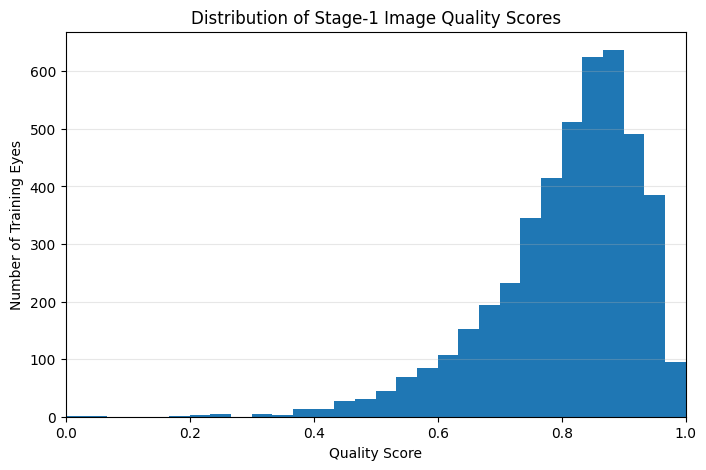

In [56]:
# ============================================================
# QUALITY SCORE DISTRIBUTION
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    stage1_quality_df["quality_score"],
    bins=30
)

plt.xlabel("Quality Score")
plt.ylabel("Number of Training Eyes")
plt.title("Distribution of Stage-1 Image Quality Scores")

plt.xlim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.show()